### Q2(a) SVM with C = 1.0

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Load dataset
csv_path = "../mobile_price.csv"
df = pd.read_csv(csv_path)

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [13]:
# Split features and target
X = df.drop(columns=["price_range"])
y = df["price_range"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:")
print(y.value_counts().sort_index())

X shape: (2000, 20)
y shape: (2000,)
Class distribution:
price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


In [14]:
# First split: 60% training, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    shuffle=True,
    stratify=y
)

# Second split: 20% validation, 20% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (1200, 20) (1200,)
Validation set: (400, 20) (400,)
Testing set: (400, 20) (400,)


In [15]:
# Train SVM classifier with C = 1.0
svm_model = SVC(C=1.0)

svm_model.fit(X_train, y_train)

# Predictions
y_train_pred = svm_model.predict(X_train)
y_val_pred = svm_model.predict(X_val)
y_test_pred = svm_model.predict(X_test)

# Evaluation
q2a_results = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Testing"],
    "Accuracy": [
        accuracy_score(y_train, y_train_pred),
        accuracy_score(y_val, y_val_pred),
        accuracy_score(y_test, y_test_pred)
    ],
    "F1-score": [
        f1_score(y_train, y_train_pred, average="macro"),
        f1_score(y_val, y_val_pred, average="macro"),
        f1_score(y_test, y_test_pred, average="macro")
    ]
})

q2a_results

,Dataset,Accuracy,F1-score
0,Training,0.941667,0.941414
1,Validation,0.952500,0.952357
2,Testing,0.955000,0.954755


### Q2(b) Explore different C values

In [16]:
# Question 2(b): Explore different C values

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

svm_results = []

for C in C_values:
    model = SVC(C=C)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    
    svm_results.append({
        "C": C,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train F1-score": f1_score(y_train, train_pred, average="macro"),
        "Validation F1-score": f1_score(y_val, val_pred, average="macro"),
        "Test F1-score": f1_score(y_test, test_pred, average="macro")
    })

svm_results_df = pd.DataFrame(svm_results)
svm_results_df

,C,Train Accuracy,Validation Accuracy,Test Accuracy,Train F1-score,Validation F1-score,Test F1-score
0,0.001,0.806667,0.7925,0.8125,0.804374,0.792424,0.810818
1,0.010,0.806667,0.7925,0.8125,0.804374,0.792424,0.810818
2,0.100,0.890833,0.8875,0.9000,0.890473,0.887925,0.899747
3,1.000,0.941667,0.9525,0.9550,0.941414,0.952357,0.954755
4,10.000,0.963333,0.9675,0.9600,0.963369,0.967509,0.959999
5,100.000,0.975833,0.9775,0.9775,0.975826,0.977574,0.977485
6,1000.000,0.985833,0.9775,0.9900,0.985825,0.977560,0.990012
7,10000.000,0.991667,0.9725,0.9825,0.991667,0.972642,0.982549


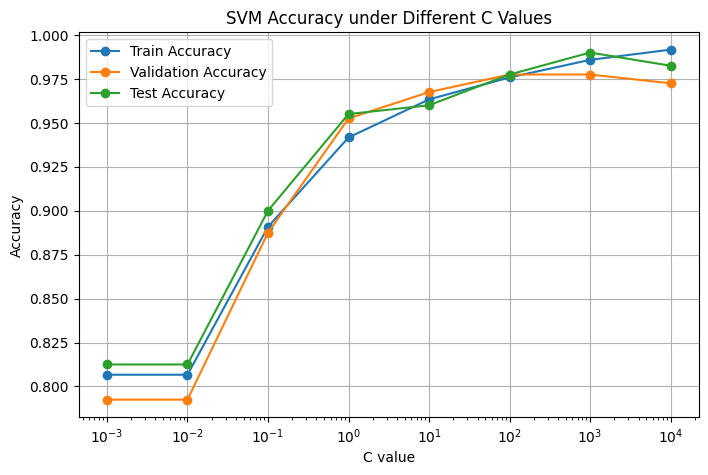

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(svm_results_df["C"], svm_results_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(svm_results_df["C"], svm_results_df["Validation Accuracy"], marker="o", label="Validation Accuracy")
plt.plot(svm_results_df["C"], svm_results_df["Test Accuracy"], marker="o", label="Test Accuracy")

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy under Different C Values")
plt.legend()
plt.grid(True)
plt.show()

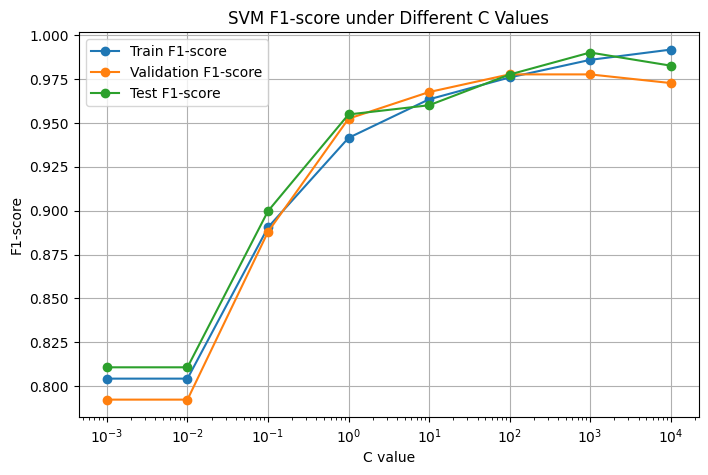

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(svm_results_df["C"], svm_results_df["Train F1-score"], marker="o", label="Train F1-score")
plt.plot(svm_results_df["C"], svm_results_df["Validation F1-score"], marker="o", label="Validation F1-score")
plt.plot(svm_results_df["C"], svm_results_df["Test F1-score"], marker="o", label="Test F1-score")

plt.xscale("log")
plt.xlabel("C value")
plt.ylabel("F1-score")
plt.title("SVM F1-score under Different C Values")
plt.legend()
plt.grid(True)
plt.show()